In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('data_science_job.csv')

In [14]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [15]:
#missing data
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [16]:
df.shape

(19158, 13)

In [17]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() >0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [18]:
df[cols].sample()

,city_development_index,enrolled_university,education_level,experience,training_hours
15141,0.92,no_enrollment,Graduate,20.0,46.0


In [19]:
len(df[cols].dropna())/ len(df)

0.8968577095730244

In [20]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

In [21]:
new_df.hist(bins==50, density=True, figsize=(12,12))
plt.show()

NameError: name 'bins' is not defined

AttributeError: Rectangle.set() got an unexpected keyword argument 'colur'

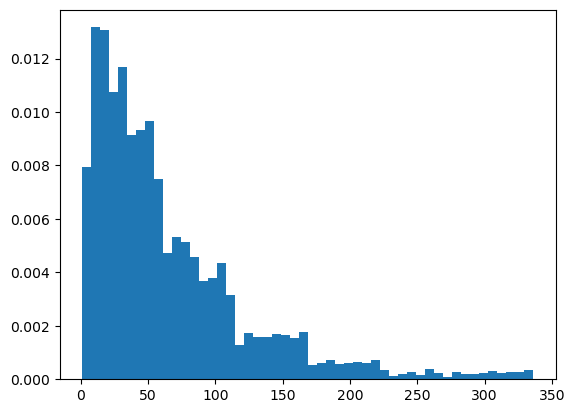

In [22]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original data
df['training_hours'].hist(bins=50, ax=ax, density=True, colur='red')


#data after cca. the argumentalpha makes the colour transparent,so we can see the overlay of the two distributions
new_df['training_hours'].hist(bins=50, ax=ax, colur='green', density=True, alpha=0.8)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original data
df['experience'].hist(bins=50, ax=ax, density=True, colur='red')


#data after cca. the argumentalpha makes the colour transparent,so we can see the overlay of the two distributions
new_df['experience'].hist(bins=50, ax=ax, colur='green', density=True, alpha=0.8)

In [23]:
temp = pd.concate([
    #percentage of observations per category, original data
    df['enrolled_university'].value_counts() / len(df),

    #percentage of observations per category, cca data
     new_df['enrolled_university'].value_counts() / len(new_df)
], axis=1)
 #add column names
temp.columns = ['original', 'cca']

temp

AttributeError: module 'pandas' has no attribute 'concate'